<a href="https://colab.research.google.com/github/twyeh/highenergy/blob/main/B_Decays_Data_Collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[PDG API](https://pdgapi.lbl.gov/doc/pythonapi.html#requirements)
The pdg package is released as open source software and can be found at github.com/particledatagroup/api.

Requirements
The PDG Python API supports Python 3 and requires SQLAlchemy version 1.4 or greater. For the time being, Python 2.7 is still supported.

Tutorial
A Jupyter notebook with a comprehensive tutorial on how to use the PDG Python API is available on github.

Installation
The PDG Python API can be installed like any other Python package available from PyPI.

For example, the following commands will first create and activate a Python 3 virtual environment using venv and then download and install package pdg and its dependencies:


```
python3 -m venv pdg.venv
source pdg.venv/bin/activate
python -m pip install pdg`
# 此內容會顯示為程式碼
```


(Use virtualenv instead of venv for Python versions below 3.3.)

If a Python virtual environment was already activated, only the following command is needed
```
python -m pip install pdg
```

In [9]:
!pip install pdg

In [10]:
import pdg
api = pdg.connect()

def filter_two_meson_k_pi_decays(particle_name):
    print(f"\nCollecting decays for {particle_name} with exactly two final state mesons (K and pi)...")
    found_any = False
    decay_data = []
    particle = api.get_particle_by_name(particle_name)
    if not particle:
        print(f"Particle {particle_name} not found.")
        return []

    for bf in particle.exclusive_branching_fractions():
        decay_products = [p.item.name for p in bf.decay_products]

        # Check for exactly two decay products
        if len(decay_products) == 2:
            p1_name = decay_products[0]
            p2_name = decay_products[1]

            # Check if one product contains 'K' and the other contains 'pi'
            is_k_and_pi = ('K' in p1_name and 'pi' in p2_name) or ('pi' in p1_name and 'K' in p2_name)

            if is_k_and_pi:
                decay_data.append({
                    'Particle': particle_name,
                    'Decay': bf.description,
                    'Branching Ratio': bf.value,
                    'Is Limit': bf.is_limit
                })
                found_any = True
    if not found_any:
        print(f"  No decays found for {particle_name} with exactly two final state K and pi mesons.")
    return decay_data


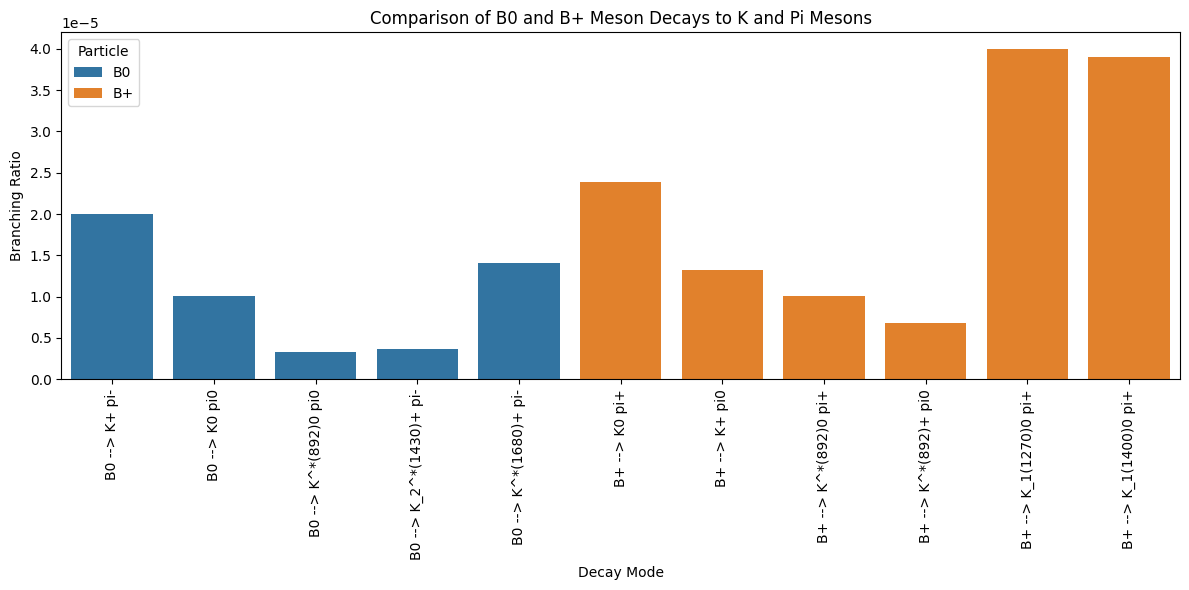

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot to compare branching ratios
plt.figure(figsize=(12, 6))
sns.barplot(data=df_combined_k_pi, x='Decay', y='Branching Ratio', hue='Particle')
plt.title('Comparison of B0 and B+ Meson Decays to K and Pi Mesons')
plt.xlabel('Decay Mode')
plt.ylabel('Branching Ratio')
plt.xticks(rotation=90)
plt.legend(title='Particle')
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd

b0_k_pi_decays = filter_two_meson_k_pi_decays('B0')
b_plus_k_pi_decays = filter_two_meson_k_pi_decays('B+')

df_b0_k_pi = pd.DataFrame(b0_k_pi_decays)
df_b_plus_k_pi = pd.DataFrame(b_plus_k_pi_decays)

df_combined_k_pi = pd.concat([df_b0_k_pi, df_b_plus_k_pi], ignore_index=True)

print("\nCombined DataFrame of B0 and B+ decays to K and pi mesons:")
display(df_combined_k_pi.head())




Combined DataFrame of B0 and B+ decays to K and pi mesons:


,Particle,Decay,Branching Ratio,Is Limit
0,B0,B0 --> K+ pi-,0.000020,False
1,B0,B0 --> K0 pi0,0.000010,False
2,B0,B0 --> K^*(892)0 pi0,0.000003,False
3,B0,B0 --> K_2^*(1430)+ pi-,0.000004,False
4,B0,B0 --> K^*(1680)+ pi-,0.000014,False


In [7]:
print("\nTop 10 B0 and B+ decays to K and pi mesons by Branching Ratio:")
display(df_combined_k_pi.sort_values(by='Branching Ratio', ascending=False).head(10))


Top 10 B0 and B+ decays to K and pi mesons by Branching Ratio:


,Particle,Decay,Branching Ratio,Is Limit
9,B+,B+ --> K_1(1270)0 pi+,0.000040,True
10,B+,B+ --> K_1(1400)0 pi+,0.000039,True
5,B+,B+ --> K0 pi+,0.000024,False
0,B0,B0 --> K+ pi-,0.000020,False
4,B0,B0 --> K^*(1680)+ pi-,0.000014,False
6,B+,B+ --> K+ pi0,0.000013,False
1,B0,B0 --> K0 pi0,0.000010,False
7,B+,B+ --> K^*(892)0 pi+,0.000010,False
8,B+,B+ --> K^*(892)+ pi0,0.000007,False
3,B0,B0 --> K_2^*(1430)+ pi-,0.000004,False


In [11]:
df_combined_k_pi.to_csv('combined_k_pi_decays.csv', index=False)
print('Data saved to combined_k_pi_decays.csv')

Data saved to combined_k_pi_decays.csv


In [22]:
import pdg
api = pdg.connect()

def filter_two_meson_decays(parent_particle_name,decay_particle_A_name,decay_particle_B_name):
    print(f"\nCollecting decays for {parent_particle_name} with exactly two final state mesons ({decay_particle_A_name} and {decay_particle_B_name})...")
    found_any = False
    decay_data = []
    particle = api.get_particle_by_name(parent_particle_name)

    if not particle:
        print(f"Particle {parent_particle_name} not found.")
        return []

    for bf in particle.exclusive_branching_fractions():
        decay_products = [p.item.name for p in bf.decay_products]

        # Check for exactly two decay products
        if len(decay_products) == 2:
            p1_name = decay_products[0]
            p2_name = decay_products[1]

            # Check if one product contains decay_particle_A_name and the other contains decay_particle_B_name
            is_k_and_pi = (decay_particle_A_name in p1_name and decay_particle_B_name in p2_name) or \
                          (decay_particle_B_name in p1_name and decay_particle_A_name in p2_name)

            if is_k_and_pi:
                decay_data.append({
                    'Particle': parent_particle_name,
                    'Decay': bf.description,
                    'Branching Ratio': bf.value,
                    'Is Limit': bf.is_limit
                })
                found_any = True
    if not found_any:
        print(f"  No decays found for {parent_particle_name} with exactly two final state {decay_particle_A_name} and {decay_particle_B_name} mesons.")
    return decay_data

In [26]:
import pandas as pd

b0_k_pi_decays = filter_two_meson_decays('B0','K','pi')
b_plus_k_pi_decays = filter_two_meson_decays('B+','K','pi')

df_b0_k_pi = pd.DataFrame(b0_k_pi_decays)
df_b_plus_k_pi = pd.DataFrame(b_plus_k_pi_decays)

df_combined_k_pi = pd.concat([df_b0_k_pi, df_b_plus_k_pi], ignore_index=True)

print("\nCombined DataFrame of B0 and B+ decays to K and pi mesons:")
#display(df_combined_k_pi.head())
display(df_b0_k_pi.head())
display(df_b_plus_k_pi.head())




Combined DataFrame of B0 and B+ decays to K and pi mesons:


,Particle,Decay,Branching Ratio,Is Limit
0,B0,B0 --> K+ pi-,0.000020,False
1,B0,B0 --> K0 pi0,0.000010,False
2,B0,B0 --> K^*(892)0 pi0,0.000003,False
3,B0,B0 --> K_2^*(1430)+ pi-,0.000004,False
4,B0,B0 --> K^*(1680)+ pi-,0.000014,False


,Particle,Decay,Branching Ratio,Is Limit
0,B+,B+ --> K0 pi+,0.000024,False
1,B+,B+ --> K+ pi0,0.000013,False
2,B+,B+ --> K^*(892)0 pi+,0.000010,False
3,B+,B+ --> K^*(892)+ pi0,0.000007,False
4,B+,B+ --> K_1(1270)0 pi+,0.000040,True


In [ ]:
import pdg
api = pdg.connect()

def get_b_to_k_pi_decays_and_acp():
    print("Collecting Branching Ratios and ACP for B to K pi decays:\n")

    particles = ['B0', 'B+'] # Consider both B0 and B+

    for particle_name in particles:
        print(f"--- {particle_name} to K pi Decays (Branching Ratios) ---")
        found_k_pi_decay = False
        for bf in api.get_particle_by_name(particle_name).exclusive_branching_fractions():
            decay_products = [p.item.name for p in bf.decay_products]
            has_k = any('K' in p for p in decay_products)
            has_pi = any('pi' in p for p in decay_products)
            if has_k and has_pi:
                print(f"  Decay: {bf.description:<50}  Branching Ratio: {bf.value} (Is Limit: {bf.is_limit})")
                found_k_pi_decay = True
        if not found_k_pi_decay:
            print(f"  No K pi decays found for {particle_name} from exclusive branching fractions.")
        print("-" * 70)

        print(f"--- {particle_name} CP Violation Parameters (ACP for K pi) ---")
        found_acp_for_k_pi = False
        # FIX: Use .properties() instead of .cp_violation_parameters() and filter
        particle_properties = api.get_particle_by_name(particle_name).properties()
        for param in particle_properties:
            desc_lower = param.description.lower()
            # Look for ACP specifically for K and pi in the description
            if 'acp' in desc_lower and ('k' in desc_lower and 'pi' in desc_lower):
                print(f"  Parameter: {param.description:<50}  Value: {param.value} (Is Limit: {param.is_limit})")
                found_acp_for_k_pi = True
        if not found_acp_for_k_pi:
            print(f"  No explicit ACP parameters for K pi decays found for {particle_name}.")
        print("=" * 70)

get_b_to_k_pi_decays_and_acp()



--- B0 to K pi Decays (Branching Ratios) ---
  Decay: B0 --> D- K+ pi+ pi-                                Branching Ratio: 0.0003530128447741347 (Is Limit: False)
  Decay: B0 --> D^*(2010)- K0 pi+                            Branching Ratio: 0.0003 (Is Limit: False)
  Decay: B0 --> D^*(2010)- K+ pi- pi+                        Branching Ratio: 0.0004664268810691488 (Is Limit: False)
  Decay: B0 --> D_s0(2317)- K+ , D_s0()- --> D_s()- pi0      Branching Ratio: 4.24762735152158e-05 (Is Limit: False)
  Decay: B0 --> D_sJ(2457)- K+ , D_sJ()- --> D_s()- pi0      Branching Ratio: 9.4e-06 (Is Limit: True)
  Decay: B0 --> D_s()- pi+ K0                                Branching Ratio: 9.69575757575758e-05 (Is Limit: False)
  Decay: B0 --> D_s^*()- pi+ K0                              Branching Ratio: 0.00011 (Is Limit: True)
  Decay: B0 --> D_s()- K+ pi+ pi-                            Branching Ratio: 0.00017121991091463 (Is Limit: False)
  Decay: B0 --> D_s()- pi+ K^*(892)0                       

In [ ]:
import pdg
api = pdg.connect()

def find_cp_violating_decays(particle_name):
    print(f"\nCP-violating decay modes for {particle_name}:")
    found_any = False
    for bf in api.get_particle_by_name(particle_name).exclusive_branching_fractions():
        # Common keywords indicating CP violation or asymmetry studies
        cp_keywords = ['cp', 'asymmetry', 'acp']
        if any(keyword in bf.description.lower() for keyword in cp_keywords):
            print('%-60s    %4s    %s' % (bf.description, bf.is_limit, bf.value))
            found_any = True
    if not found_any:
        print("No explicit CP-violating modes found in descriptions.")

find_cp_violating_decays('B0')



CP-violating decay modes for B0:
B0 --> D+- D^*()-+ (CP-averaged)                                False    0.000614


$$
Br(B^0\to\pi^0\pi^0)=(1.25\pm0.23)\times 10^{-6}
$$
$$
A_{CP}=0.03\pm0.30
$$

In [ ]:
import pdg
api = pdg.connect()
for bf in api.get_particle_by_name('B+').exclusive_branching_fractions():
    print('%-60s    %4s    %s' % (bf.description, bf.is_limit, bf.value))

B+ --> mu+ mu- mu+ nu_mu                                        True    1.6e-08
B+ --> Dbar0 pi+                                                False    0.004613493720223471
B+ --> Dbar0 rho+                                               False    0.00972130262693794
B+ --> Dbar0 K+                                                 False    0.0003638701305502509
B+ --> D0 K+                                                    False    3.595036889836481e-06
B+ --> [ K- pi+ ](D) K+                                         True    2.8e-07
B+ --> [ K+ pi- ](D) K+                                         True    1.6e-05
B+ --> [ K- pi+ pi0 ](D) K+                                     False    None
B+ --> [ K+ pi- pi0 ](D) K+                                     False    None
B+ --> [ K- pi+ pi+ pi- ](D) K+                                 False    None
B+ --> [ K+ pi- pi+ pi- ](D) K+                                 False    None
B+ --> [ K- pi+ ](D) pi+                                        False  

In [ ]:
import pdg
api = pdg.connect()
for bf in api.get_particle_by_name('B0').exclusive_branching_fractions():
    print('%-60s    %4s    %s' % (bf.description, bf.is_limit, bf.value))

B0 --> D- pi+                                                   False    0.00250609028169199
B0 --> D- rho+                                                  False    0.00757533218537572
B0 --> D- K^*(892)+                                             False    0.000445777202072539
B0 --> D- omega pi+                                             False    0.0028
B0 --> D- K+                                                    False    0.0002051413814562231
B0 --> D- K+ pi+ pi-                                            False    0.0003530128447741347
B0 --> D- K+ Kbar0                                              False    0.000164
B0 --> D- K+ Kbar^*(892)0                                       False    0.000767299377446216
B0 --> Dbar0 pi+ pi-                                            False    0.000880259859090493
B0 --> D^*(2010)- pi+                                           False    0.00265911176393428
B0 --> Dbar0 K+ K-                                              False    6.073793027724

In [ ]:
import pdg
api = pdg.connect()

for decay in api.get_particle_by_name('B0').exclusive_branching_fractions():
    decay_products = [p.item.name for p in decay.decay_products]
    if 'J/psi(1S)' in decay_products:
        print(format(decay.description,'40s'), decay.display_value_text)

B0 --> J/psi(1S) K0                      (8.91+-0.21)E-4
B0 --> J/psi(1S) K+ pi-                  (1.15+-0.05)E-3
B0 --> J/psi(1S) eta K0S                 (5.4+-0.9)E-5
B0 --> J/psi(1S) eta^' K0S               <2.5E-5
B0 --> J/psi(1S) phi K0                  (4.9+-1.0)E-5
B0 --> J/psi(1S) omega K0                (2.3+-0.4)E-4
B0 --> J/psi(1S) K(1270)0                (1.3+-0.5)E-3
B0 --> J/psi(1S) pi0                     (1.65+-0.08)E-5
B0 --> J/psi(1S) eta                     (1.08+-0.23)E-5
B0 --> J/psi(1S) pi+ pi-                 (3.99+-0.15)E-5
B0 --> J/psi(1S) omega                   (1.8+0.7-0.5)E-5
B0 --> J/psi(1S) K+ K-                   (2.53+-0.35)E-6
B0 --> J/psi(1S) phi                     <1.1E-7
B0 --> J/psi(1S) eta^'(958)              (7.6+-2.4)E-6
B0 --> J/psi(1S) K0 pi+ pi-              (4.5+-0.4)E-4
B0 --> J/psi(1S) K0 K+ K-                (2.5+-0.7)E-5
B0 --> J/psi(1S) K^*(892)+ pi-           (8+-4)E-4
B0 --> J/psi(1S) pi+ pi- pi+ pi-         (1.44+-0.12)E-5
B0 --> J/

In [ ]:
!pip install pdg
import pdg
api = pdg.connect()

def find_k_pi_decays(particle_name):
    print(f"\nDecays for {particle_name} containing K and pi:")
    for bf in api.get_particle_by_name(particle_name).exclusive_branching_fractions():
        decay_products = [p.item.name for p in bf.decay_products]
        # Check if any product contains 'K' and any product contains 'pi'
        has_k = any('K' in p for p in decay_products)
        has_pi = any('pi' in p for p in decay_products)
        if has_k and has_pi:
            print('%-60s    %4s    %s' % (bf.description, bf.is_limit, bf.value))

find_k_pi_decays('B0')
find_k_pi_decays('B+')



Decays for B0 containing K and pi:
B0 --> D- K+ pi+ pi-                                            False    0.0003530128447741347
B0 --> D^*(2010)- K0 pi+                                        False    0.0003
B0 --> D^*(2010)- K+ pi- pi+                                    False    0.0004664268810691488
B0 --> D_s0(2317)- K+ , D_s0()- --> D_s()- pi0                  False    4.24762735152158e-05
B0 --> D_sJ(2457)- K+ , D_sJ()- --> D_s()- pi0                  True    9.4e-06
B0 --> D_s()- pi+ K0                                            False    9.69575757575758e-05
B0 --> D_s^*()- pi+ K0                                          True    0.00011
B0 --> D_s()- K+ pi+ pi-                                        False    0.00017121991091463
B0 --> D_s()- pi+ K^*(892)0                                     True    0.003
B0 --> D_s^*()- pi+ K^*(892)0                                   True    0.0016
B0 --> Dbar0 K+ pi-                                             False    8.8e-05
B0 --> [ pi+ pi